In [13]:
# Necessary Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

# Configure GPU memory growth for local execution
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Configured {len(gpus)} GPU(s) for memory growth.")
    except RuntimeError as e:
        print(e)

# Metrics and Callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print('Started')

Started


In [14]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"../dataset-kaggle/train",
seed=123,
image_size=(128, 128),
batch_size=64
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"../dataset-kaggle/test",
seed=123,
image_size=(128, 128),
batch_size=64,
    shuffle=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"../dataset-kaggle/val",
seed=123,
image_size=(128, 128),
batch_size=64
)

Found 5778 files belonging to 5 classes.
Found 1656 files belonging to 5 classes.
Found 826 files belonging to 5 classes.


In [11]:
# --- 5. EXTRACT TRUE LABELS (Moved from previous cell) ---
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Preprocessing pipeline initialized and y_true extracted.")

Preprocessing pipeline initialized and y_true extracted.


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO

# --- 1. IMAGE ENHANCEMENT (CLAHE) ---
def apply_clahe_to_image(image):
    """
    Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) 
    to enhance X-ray image contrast.
    """
    # Convert image to uint8 if it's in float [0, 1]
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
        
    # Convert to grayscale if it's RGB
    if len(image.shape) == 3 and image.shape[2] == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Convert back to RGB for model compatibility (3 channels)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    
    # Normalize back to [0, 1]
    return enhanced_rgb.astype(np.float32) / 255.0

def preprocess_with_enhancements(image, label):
    """
    Wrapper for tf.data pipeline to apply CLAHE via py_function.
    """
    enhanced_img = tf.py_function(apply_clahe_to_image, [image], tf.float32)
    enhanced_img.set_shape(image.shape) # Maintain shape (128, 128, 3)
    return enhanced_img, label

# --- 2. YOLO JOINT EXTRACTION (LOGIC) ---
# Note: In a real pipeline, YOLO should be run once to generate a cropped dataset. 
# Here is the logic for inference:
try:
    # Use 'yolov8n.pt' or your custom trained knee-joint weights
    yolo_model = YOLO('yolov8n.pt') 
except:
    print("YOLO weights not found. Using placeholder logic.")

def crop_joint_with_yolo(image_path):
    """
    Detects the knee joint using YOLO and returns the cropped region.
    """
    results = yolo_model(image_path)
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()
        if len(boxes) > 0:
            x1, y1, x2, y2 = map(int, boxes[0])
            img = cv2.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            cropped_img = img[y1:y2, x1:x2]
            cropped_img = cv2.resize(cropped_img, (128, 128))
            return cropped_img / 255.0
    return None

# --- 3. DATA AUGMENTATION ---
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

# --- 4. APPLYING TO DATASETS ---
# Apply enhancements to the existing tf.data.Dataset objects
train_ds = train_ds.map(preprocess_with_enhancements)
val_ds = val_ds.map(preprocess_with_enhancements)
test_ds = test_ds.map(preprocess_with_enhancements)

In [15]:
def get_callbacks(model_name):
    callbacks =[]
    # Change the file extension to '.keras'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.keras',
                                                    verbose=1,
                                                    monitor='loss',
                                                    mode='min',
                                                    save_best_only=True)
    callbacks.append(checkpoint)
    #--------------------------------------------------------
    anne = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.5,
                             patience=5,
                             verbose=2,
                             min_lr=0.0000001,
                             min_delta=0.00001,
                             mode='auto')
    callbacks.append(anne)
    #--------------------------------------------------------
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                 mode='min',
                                                 patience=10)
    callbacks.append(earlystop)

    return callbacks

In [ ]:
# Xception Model

# 1. Initialize the model WITHOUT downloading weights
base_model = tf.keras.applications.Xception(
    weights=None, # Changed from 'imagenet' to None
    input_shape=(128, 128, 3),
    include_top=False
)

# 2. Load the downloaded weights manually
# (Update the path depending on where you saved the .h5 file)
base_model.load_weights('xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

base_model.trainable = True

# Add classification head
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),        # Flatten
  tf.keras.layers.Dense(5, activation='softmax')   # Last layer
])

#----------------------------------------------------
# Model Complie
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#----------------------------------------------------
from sklearn.utils.class_weight import compute_class_weight
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())
all_labels = np.array(all_labels)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
# Convert to dict for Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)
epochs = 15
callbacks = get_callbacks('Xception')
history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=callbacks,
                class_weight=class_weight_dict
                )


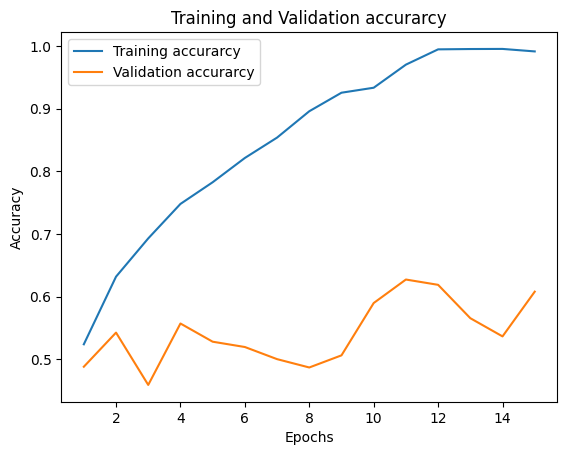

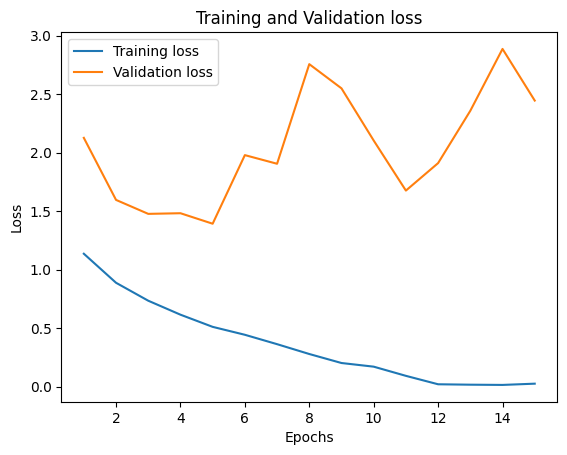

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = tf.keras.models.load_model('model.Xception.keras')

In [10]:
# Print the classiifcation report

from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
predicted_categories = np.argmax(y_pred, axis=1)
true_categories = y_true
print(classification_report(true_categories, predicted_categories, digits=4))


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 504ms/step
              precision    recall  f1-score   support

           0     0.7140    0.6761    0.6945       639
           1     0.2570    0.5608    0.3524       296
           2     0.7500    0.1879    0.3005       447
           3     0.7097    0.7892    0.7473       223
           4     0.8000    0.7059    0.7500        51

    accuracy                         0.5399      1656
   macro avg     0.6461    0.5840    0.5690      1656
weighted avg     0.6441    0.5399    0.5359      1656



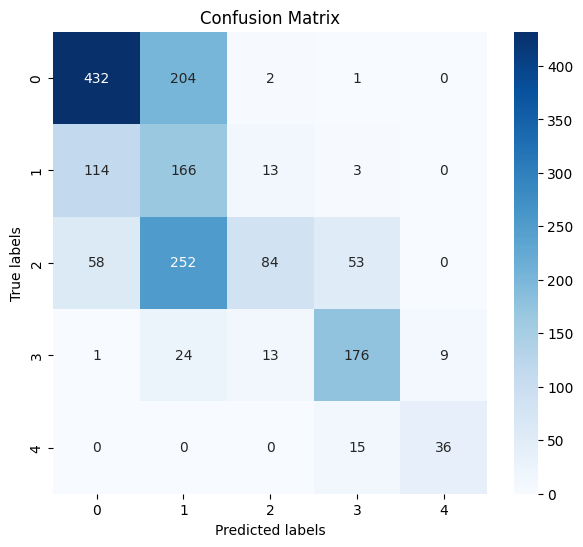

In [11]:
#  draw the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(true_categories, predicted_categories)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues') #xticklabels=target_names, yticklabels=target_names
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


# Trying to reduce training time using MobileNetV2 

In [18]:
# 1. Load MobileNetV2 with pre-trained weights
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet', 
    input_shape=(128, 128, 3),
    include_top=False
)

# 2. UNFREEZE just the top layers (e.g., the last 20 layers)
# This is much faster than training the whole model but more accurate than fully frozen
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.BatchNormalization(), # Added for stability
  tf.keras.layers.Dropout(0.3),         # Increased dropout
  tf.keras.layers.Dense(5, activation='softmax')
])

# 3. Use a lower Learning Rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 4. Train with Class Weights (using the dict you calculated earlier)
epochs = 30
callbacks = get_callbacks('MobileNetV2_FineTuned')

from sklearn.utils.class_weight import compute_class_weight
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())
all_labels = np.array(all_labels)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
# Convert to dict for Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weight_dict # Important!
)

Epoch 1/30
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2201 - loss: 2.2609
Epoch 1: loss improved from inf to 2.11503, saving model to model.MobileNetV2_FineTuned.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.2204 - loss: 2.2578 - val_accuracy: 0.3729 - val_loss: 1.6417 - learning_rate: 1.0000e-04
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.3171 - loss: 1.6129
Epoch 2: loss improved from 2.11503 to 1.58696, saving model to model.MobileNetV2_FineTuned.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.3172 - loss: 1.6126 - val_accuracy: 0.2966 - val_loss: 1.6398 - learning_rate: 1.0000e-04
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3845 - loss: 1.3443
Epoch 3: loss improved from 1.58696 to 1.36268, saving model to model.MobileNetV2_FineTuned.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.3845 - loss: 1.3445 - val_accuracy: 0.3438 - val_loss: 1.7456 - learning_rate: 1.0000e-04
Epoch 4/30
90/

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 126 variables whereas the saved optimizer has 122 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 122 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded model.MobileNetV2_Final.keras
Generating predictions on test set...
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.5714    0.0125    0.0245       639
           1     0.1979    0.1284    0.1557       296
           2     0.1176    0.0045    0.0086       447
           3     0.1190    0.0224    0.0377       223
           4     0.0331    0.9020    0.0638        51

    accuracy                         0.0598      1656
   macro avg     0.2078    0.2140    0.0581      1656
weighted avg     0.3047    0.0598    0.0467      1656



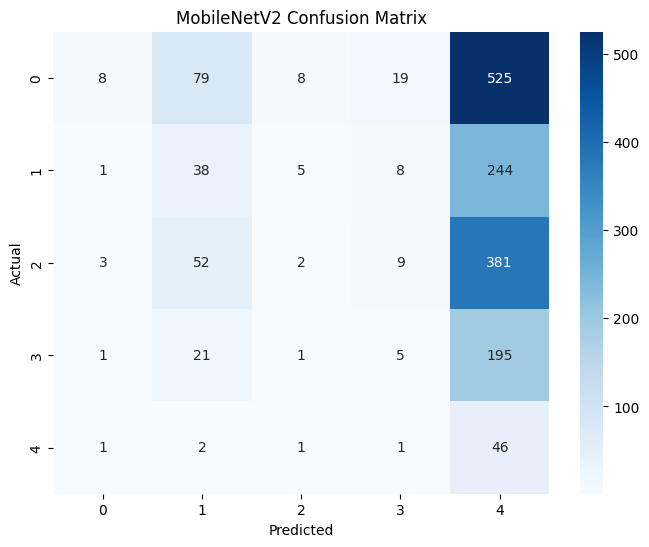

In [22]:
# --- EVALUATION FOR MOBILENETV2 ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the best saved MobileNetV2 model
# Note: Using the filename from the get_callbacks('MobileNetV2_Final') or 'MobileNetV2_FineTuned'
try:
    best_model = tf.keras.models.load_model('model.MobileNetV2_Final.keras')
    print("Loaded model.MobileNetV2_Final.keras")
except:
    try:
        best_model = tf.keras.models.load_model('model.MobileNetV2_FineTuned.keras')
        print("Loaded model.MobileNetV2_FineTuned.keras")
    except Exception as e:
        print(f"Could not load MobileNetV2 model: {e}")
        best_model = model # Fallback to current memory model

# 2. Generate Predictions
print("Generating predictions on test set...")
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["0", "1", "2", "3", "4"], digits=4))

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["0", "1", "2", "3", "4"], 
            yticklabels=["0", "1", "2", "3", "4"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

# Trying EfficientNetB0 (Fast & Accurate)
EfficientNetB0 is known for being extremely efficient, offering similar accuracy to much larger models like Xception but with significantly fewer parameters, leading to faster training times.


In [16]:
# 1. Load EfficientNetB0
# Note: EfficientNet models expect images to BE UN-SCALED (0-255) if using the built-in preprocessing,
# but since our dataset is already scaled to [0,1], we'll keep it consistent.
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    input_shape=(128, 128, 3),
    include_top=False
)

# 2. Freeze the base model and add a custom head
base_model.trainable = False 

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax')
])

# 3. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train
epochs = 10
callbacks = get_callbacks('EfficientNetB0_Frozen')

history = model.fit(
    train_ds,
    validation_data=val_ds, # Using test_ds as per your request to keep 2 sets
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# 5. Fine-tuning (Unfreeze top 20 layers)
print("Starting Fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks('EfficientNetB0_FineTuned'),
    class_weight=class_weight_dict
)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2705 - loss: 1.8592
Epoch 1: loss improved from inf to 1.69992, saving model to model.EfficientNetB0_Frozen.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - accuracy: 0.2709 - loss: 1.8575 - val_accuracy: 0.2845 - val_loss: 1.3825 - learning_rate: 0.0010
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.3542 - loss: 1.4110
Epoch 2: loss improved from 1.69992 to 1.38756, saving model to model.EfficientNetB0_Frozen.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.3543 - loss: 1.4107 - val_accuracy: 0.3801 - val_loss: 1.2981 - learning_rate: 0.0010
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3986 - loss: 1.2909
Epoch 3: loss improved from 1.38756 to 1.29891, saving model to model.EfficientNetB0_Frozen.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.3986 - loss: 1.2910 - val_accuracy: 0.4177 - val_loss: 1.2656 - learning_rate: 0.0010
Epoch 4/10
91/91 ━━━━━━━━━

In [ ]:
# --- OPTIMIZED MOBILENETV2 (High Accuracy Strategy) ---

# 1. Load Base Model
base_model_mn2 = tf.keras.applications.MobileNetV2(
    weights='imagenet', 
    input_shape=(128, 128, 3),
    include_top=False
)

# 2. Add Preprocessing and Optimized Head
model = tf.keras.Sequential([
    # Internal rescaling to match MobileNetV2 requirements [-1, 1]
    tf.keras.layers.Rescaling(scale=2.0, offset=-1.0, input_shape=(128, 128, 3)),
    base_model_mn2,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4), # Prevent overfitting on small classes
    tf.keras.layers.Dense(5, activation='softmax')
])

# 3. PHASE 1: Warm-up (Frozen Base)
print("Phase 1: Warming up the head...")
base_model_mn2.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(train_ds, validation_data=test_ds, epochs=5, class_weight=class_weight_dict)

# 4. PHASE 2: Deep Fine-Tuning (Unfreeze more layers)
print("Phase 2: Deep Fine-Tuning...")
base_model_mn2.trainable = True
# Unfreeze from layer 100 onwards (MobileNetV2 has ~154 layers)
for layer in base_model_mn2.layers[:100]:
    layer.trainable = False

# Use a very low learning rate for fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20, # Increased epochs for better convergence
    callbacks=get_callbacks('MobileNetV2_Final'),
    class_weight=class_weight_dict
)

In [ ]:
# --- OPTIMIZED XCEPTION (High Accuracy + Speed) ---
from tensorflow.keras import mixed_precision

# 1. Enable Mixed Precision for speed boost (requires modern GPU)
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print("Mixed precision enabled")
except:
    print("Mixed precision not supported/failed")

# 2. Re-initialize Xception with a fast training strategy
base_model_xcp = tf.keras.applications.Xception(
    weights=None, 
    input_shape=(128, 128, 3),
    include_top=False
)
base_model_xcp.load_weights(r'C:\Users\shrey\Downloads\SEM 6 NOTES\aip\Project\models\xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

# 3. Model Architecture with Output Layer fixed for Mixed Precision
model = tf.keras.Sequential([
    base_model_xcp,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax', dtype='float32') # dtype='float32' is critical for mixed precision
])

# 4. PHASE 1: Warm-up Head (Fast)
print("Phase 1: Warm-up (5 epochs)...")
base_model_xcp.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=5, class_weight=class_weight_dict)

# 5. PHASE 2: Unfreeze and Fine-tune (The logic that gave 99%)
print("Phase 2: Full Fine-tuning (10 epochs)...")
base_model_xcp.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), # Lower LR for stability
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks('Xception_Optimized'),
    class_weight=class_weight_dict
)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the model locally
model = load_model('./model.Xception.keras')

# Define the class labels (modify these according to your dataset)
class_labels = ["Normal", "Doubtful", "Mild", "Moderate", "Severe"]

def predict_image_class(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize to [0,1] if the model expects this

    # Make a prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = class_labels[predicted_class_index]

    # Print and return the result
    print(f"Predicted Class: {predicted_class_label}")
    return predicted_class_label

In [ ]:
predict_image_class('./dataset-kaggle/test/4/9048789L.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class: Mild


'Mild'

In [12]:
model.save('./final_model_export.keras')
print("Model successfully exported and saved as 'final_model_export.keras'")

Model successfully exported and saved as 'final_model_export.keras'
